# Regime Detection in U.S. Equity and Credit Markets
## 3-State Gaussian Hidden Markov Model

COMP 490 - Sheldon Soudin - 40068843


In [1]:
# imports and setup

!pip install -q yfinance fredapi hmmlearn

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
LABELS = ["Calm", "Transition", "Crisis"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.8 MB/s eta 0:00:00


In [2]:
# fred API key set up, uses colab's secret key manager, needs to bwe entered when prompted.

key = None
try:
    from google.colab import userdata
    try:
        key = userdata.get("FRED_API_KEY")
    except Exception:
        print("No Colab secret found; using prompt instead.")
except ImportError:
    pass

if not key:
    import getpass
    key = getpass.getpass("FRED API key: ")

key = key.strip()
assert re.fullmatch(r"[a-z0-9]{32}", key), f"Not a valid FRED key: {key[:20]!r}"
os.environ["FRED_API_KEY"] = key
print("Key set.")

No Colab secret found; using prompt instead.
FRED API key: ··········
Key set.


In [3]:
# dataset sourcing function  S&P from yahoo finance and high-yield and investment-grade from FRED.
# NOTE: two sources have different calendars, timezone-aware (yfinance) vs not the case for fredapi, function normalizeds before joining
# OAS series are forward-filled and prices are not

START = "2000-01-01"

def fetch_data(start=START):
    import yfinance as yf
    from fredapi import Fred

    px = yf.download("^GSPC", start=start, progress=False, auto_adjust=True)
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.get_level_values(0)
    px = px[["Close", "Volume"]]
    px.columns = ["close", "volume"]
    px.index = pd.DatetimeIndex(px.index).tz_localize(None).normalize()

    fred = Fred(api_key=os.environ["FRED_API_KEY"])
    cr = pd.DataFrame({
        "baa": fred.get_series("DBAA", observation_start=start),   # Moody's Baa yield ,
        "aaa": fred.get_series("DAAA", observation_start=start)})   # Moody's Aaa yield , both changed from midterm to get large sample
    cr.index = pd.DatetimeIndex(cr.index).tz_localize(None).normalize()

    df = px.join(cr.reindex(px.index.union(cr.index)).ffill(), how="left")
    df = df.dropna(subset=["close"]).ffill().dropna()

    print(f"S&P from {px.index.min().date()}, "
          f"Baa from {cr['baa'].first_valid_index().date()}, "
          f"Aaa from {cr['aaa'].first_valid_index().date()}")
    print(f"Aligned: {len(df)} rows, {df.index.min().date()} -> "
          f"{df.index.max().date()} (~{len(df)/252:.1f} years)")
    return df

data = fetch_data()
data.head()

S&P from 2000-01-03, Baa from 2000-01-03, Aaa from 2000-01-03
Aligned: 6694 rows, 2000-01-03 -> 2026-08-14 (~26.6 years)


,close,volume,baa,aaa
Date,,,,
2000-01-03,1455.219971,931800000,8.27,7.75
2000-01-04,1399.420044,1009000000,8.21,7.69
2000-01-05,1402.109985,1085500000,8.29,7.78
2000-01-06,1403.449951,1092300000,8.24,7.72
2000-01-07,1441.469971,1225200000,8.22,7.69


In [4]:
# preprocessing and feature engineering , needed fo the model to use pertinent information of each feature, i.e. stationary, turbulence, credit stress isolation

# Log return: price level -> stationary daily change.
# Logs make returns additive over time and roughly symmetric up vs down.

# Realized volatility: rolling std of returns = how turbulent the last month was.
# sqrt(252) rescales daily to annual

# Credit stress: HY minus IG isolates compensation for DEFAULT risk.
# The difference cancels the common move both grades share with rates.

# dropna(): drops the first VOL_WINDOW rows, where diff() and rolling()
# have no history yet.

VOL_WINDOW = 21

features = pd.DataFrame(index=data.index)
features["log_return"]    = np.log(data["close"]).diff()
features["realized_vol"]  = features["log_return"].rolling(VOL_WINDOW).std() * np.sqrt(252)
features["credit_stress"] = data["baa"] - data["aaa"]
features = features.dropna()

print(f"{len(features)} rows, {features.index.min().date()} -> "
      f"{features.index.max().date()}")
features.describe().T.round(4)

6673 rows, 2000-02-02 -> 2026-08-14


,count,mean,std,min,25%,50%,75%,max
log_return,6673.0,0.0003,0.0121,-0.1277,-0.0047,0.0006,0.0059,0.1096
realized_vol,6673.0,0.1630,0.1051,0.0347,0.0987,0.1361,0.1959,0.9756
credit_stress,6673.0,0.9945,0.4007,0.4000,0.7500,0.9100,1.1200,3.5000


In [5]:
# methods, model fitting
# Gaussian HMM assuming unobserved states {1,2,3}
# parameter estimation ;: EM(Baum-Welch) converging to a local critical point , repeated for several random initializatons and highest-likelihood model kept
# state indices are arbitrary : labelled after fitting by ranking their mean realized volatility: lowest is Calm, highest is Crisis.

def fit_hmm(X, n_states=3, n_restarts=15, cov="diag", seed=42):
    """Fit on already-standardized X, keeping the best of several restarts."""
    rng = np.random.RandomState(seed)
    best, best_ll = None, -np.inf
    for _ in range(n_restarts):
        m = GaussianHMM(n_components=n_states, covariance_type=cov,
                        n_iter=1000, tol=1e-4, random_state=rng.randint(10**6))
        try:
            m.fit(X)
            ll = m.score(X)
            if np.isfinite(ll) and ll > best_ll:
                best, best_ll = m, ll
        except Exception:
            continue
    if best is None:
        raise RuntimeError("All EM restarts failed.")
    return best, best_ll


COV, N_RESTARTS = "diag", 15
vol_idx = list(features.columns).index("realized_vol")

scaler = StandardScaler().fit(features.values)
X = scaler.transform(features.values)

model, ll = fit_hmm(X, n_restarts=N_RESTARTS, cov=COV)
order = np.argsort(model.means_[:, vol_idx])     # ascending vol -> Calm..Crisis

print(f"Log-likelihood: {ll:.1f}")
print("Raw state -> label:", {int(order[i]): LABELS[i] for i in range(3)})

Log-likelihood: -16009.5
Raw state -> label: {0: 'Calm', 2: 'Transition', 1: 'Crisis'}


In [6]:
# experiment set up and fitted model summary
# diagnostics allow to watchout for low-self persistance (self loops) and states that are practically unreachable.


# TABLE 1 -emission parameters, converted back to original units
means = pd.DataFrame(scaler.inverse_transform(model.means_[order]),
                     index=LABELS, columns=features.columns)
print("TABLE 1 - Emission means (original units)")
display(means.round(4))

# TABLE 2 - transition matrix and implied durations
A = model.transmat_[np.ix_(order, order)]
trans = pd.DataFrame(A, index=LABELS, columns=LABELS)
trans["exp_duration_days"] = 1 / (1 - np.diag(A))
print("\nTABLE 2 - Transition matrix and expected durations")
display(trans.round(4))

print("\nDIAGNOSTICS")
for i, lab in enumerate(LABELS):
    inflow = A[:, i].sum() - A[i, i]
    flag = ""
    if A[i, i] < 0.5:   flag += "  <-- not persistent"
    if inflow < 1e-3:   flag += "  <-- UNREACHABLE (degenerate)"
    print(f"  {lab:11s} self={A[i,i]:.4f}  inflow={inflow:.4f}{flag}")

TABLE 1 - Emission means (original units)


,log_return,realized_vol,credit_stress
Calm,0.0005,0.1049,0.8149
Transition,0.0000,0.2045,1.1057
Crisis,-0.0006,0.4832,2.1176



TABLE 2 - Transition matrix and expected durations


,Calm,Transition,Crisis,exp_duration_days
Calm,0.9906,0.0094,0.0000,105.9724
Transition,0.0138,0.9839,0.0023,61.9818
Crisis,0.0000,0.0181,0.9819,55.2502



DIAGNOSTICS
  Calm        self=0.9906  inflow=0.0138
  Transition  self=0.9839  inflow=0.0275
  Crisis      self=0.9819  inflow=0.0023


Regime occupancy (Viterbi):
Calm          0.5611
Transition    0.3881
Crisis        0.0508


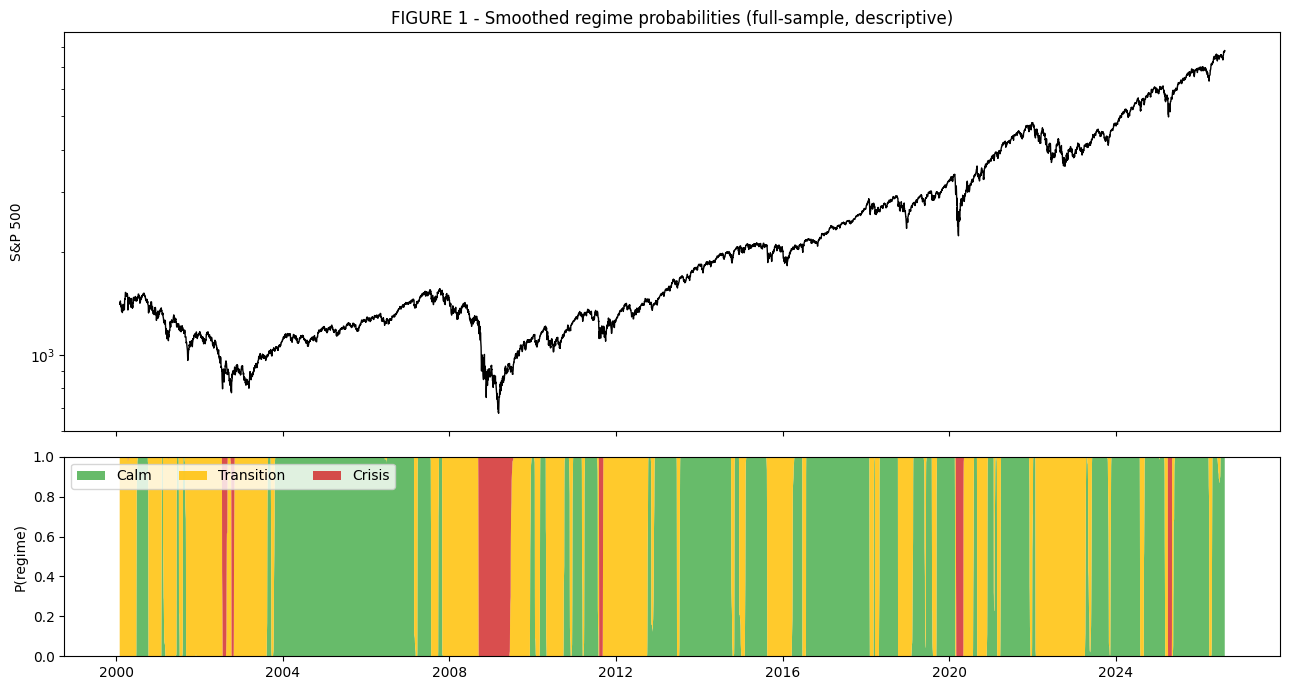

In [7]:
# Descriptive regime history

# Viterbi decoding on the full sample gives the most likely regime sequence,
# and the smoothed posterior gives the probability of each regime at each date.
# Both condition on the entire sample, so they describe history rather than forecast;

viterbi  = pd.Series(np.argsort(order)[model.predict(X)], index=features.index)
smoothed = pd.DataFrame(model.predict_proba(X)[:, order],
                        columns=LABELS, index=features.index)

print("Regime occupancy (Viterbi):")
print((viterbi.value_counts(normalize=True).sort_index()
       .rename(dict(enumerate(LABELS))).round(4)).to_string())

colors = ["#4CAF50", "#FFC107", "#D32F2F"]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a1.plot(data["close"].loc[features.index], color="black", lw=1)
a1.set_yscale("log"); a1.set_ylabel("S&P 500")
a1.set_title("FIGURE 1 - Smoothed regime probabilities (full-sample, descriptive)")
a2.stackplot(smoothed.index, [smoothed[c] for c in LABELS],
             labels=LABELS, colors=colors, alpha=0.85)
a2.set_ylim(0, 1); a2.set_ylabel("P(regime)"); a2.legend(loc="upper left", ncol=3)
plt.tight_layout(); plt.show()

Filtered state on 2026-08-14: {'Calm': np.float64(0.999), 'Transition': np.float64(0.001), 'Crisis': np.float64(0.0)}


,Calm,Transition,Crisis
1,0.990,0.010,0.000
2,0.981,0.019,0.000
3,0.972,0.028,0.000
4,0.963,0.037,0.000
5,0.954,0.045,0.000
6,0.946,0.054,0.000
7,0.938,0.062,0.000
8,0.930,0.070,0.001
9,0.922,0.077,0.001
10,0.914,0.085,0.001


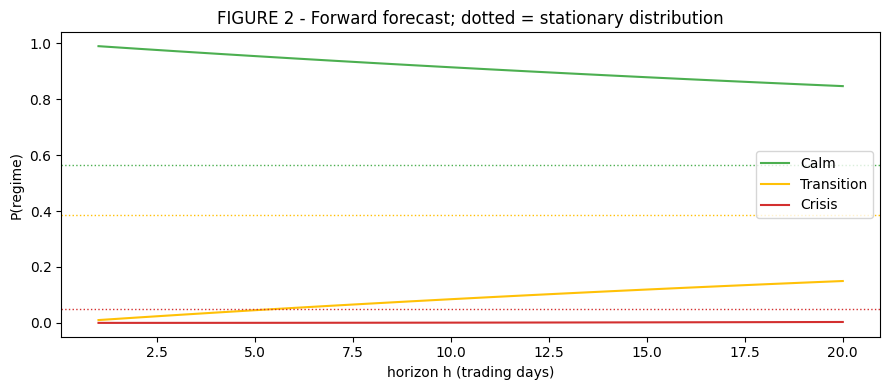

In [8]:
# Forward forecase: The predictive distribution is obtained by propagating the current filtered state through the transition matrix.
#Causal filtered posteriors P(S_t | x_1..x_t). Row t uses no data after t

def forward_filter(model, X):
    lp = np.column_stack([
        multivariate_normal.logpdf(X, model.means_[i], model.covars_[i],
                                   allow_singular=True)
        for i in range(model.n_components)])
    alpha = np.empty_like(lp)
    p = np.log(model.startprob_ + 1e-12) + lp[0]
    alpha[0] = np.exp(p - p.max()); alpha[0] /= alpha[0].sum()
    for t in range(1, len(lp)):
        p = np.log(alpha[t-1] @ model.transmat_ + 1e-12) + lp[t]
        alpha[t] = np.exp(p - p.max()); alpha[t] /= alpha[t].sum()
    return alpha


alpha = forward_filter(model, X)
assert np.allclose(forward_filter(model, X[:500]), alpha[:500], atol=1e-9)

pi, rows = alpha[-1], []
for _ in range(20):
    pi = pi @ model.transmat_
    rows.append(pi[order])
fc = pd.DataFrame(rows, index=range(1, 21), columns=LABELS)

print(f"Filtered state on {features.index[-1].date()}: "
      f"{dict(zip(LABELS, alpha[-1][order].round(3)))}")
display(fc.head(10).round(3))

ax = fc.plot(figsize=(9, 4), color=colors)
for v, c in zip(np.linalg.matrix_power(model.transmat_, 5000)[0][order], colors):
    ax.axhline(v, ls=":", lw=1, color=c)
ax.set_xlabel("horizon h (trading days)"); ax.set_ylabel("P(regime)")
ax.set_title("FIGURE 2 - Forward forecast; dotted = stationary distribution")
plt.tight_layout(); plt.show()

In [9]:
# Walk-forward one-step-ahead forecasts.
#
# Two labels:
# label_causal : argmax of the filtered posterior

# label_vol    : tercile of realized_vol
#
# Two baselines, because Calm dominates: climatology and a naive volatility-threshold rule.

def walk_forward(features, burn_in=1000, refit_every=63, n_states=3,
                 cov="diag", n_restarts=8, seed=42):
    F, dates, T = features.values, features.index, len(features)
    assert T > burn_in + 1, f"burn_in={burn_in} too large for {T} rows"
    vi = list(features.columns).index("realized_vol")
    rows, failed = [], 0

    for bi, b0 in enumerate(range(burn_in, T - 1, refit_every)):
        b1 = min(b0 + refit_every, T - 1)
        sc = StandardScaler().fit(F[:b0])                 # training data only
        try:
            m, _ = fit_hmm(sc.transform(F[:b0]), n_states, n_restarts, cov, seed + bi)
        except Exception:
            failed += 1
            continue
        o = np.argsort(m.means_[:, vi])                   # vol order -> Calm..Crisis

        # climatology from the training window's own causal decode
        tr = np.argmax(forward_filter(m, sc.transform(F[:b0]))[:, o], axis=1)
        clim = np.bincount(tr, minlength=n_states) / len(tr)

        a = forward_filter(m, sc.transform(F[:b1 + 1]))   # frozen model, filter fwd
        for t in range(b0, b1):
            p = (a[t] @ m.transmat_)[o]                   # one-step-ahead forecast
            rows.append({"date": dates[t + 1],
                         "p_calm": p[0], "p_transition": p[1], "p_crisis": p[2],
                         "label_causal": int(np.argmax(a[t + 1][o])),
                         "clim_calm": clim[0], "clim_transition": clim[1],
                         "clim_crisis": clim[2]})
    if failed:
        print(f"WARNING: {failed} block(s) failed to fit and were skipped.")
    assert rows, "No forecasts produced."
    return pd.DataFrame(rows).set_index("date")


BURN_IN, REFIT_EVERY = 1000, 63
wf = walk_forward(features, burn_in=BURN_IN, refit_every=REFIT_EVERY, cov=COV)
print(f"{len(wf)} one-step-ahead forecasts, "
      f"{wf.index[0].date()} -> {wf.index[-1].date()}")

P_hmm  = wf[["p_calm", "p_transition", "p_crisis"]]
P_clim = wf[["clim_calm", "clim_transition", "clim_crisis"]].set_axis(P_hmm.columns, axis=1)

# exogenous label and  naive volatility-threshold baseline (tercile cutoffs from burn-in only)
_fwd  = features["realized_vol"]
_cuts = np.quantile(_fwd.iloc[:BURN_IN].dropna(), [1/3, 2/3])
label_vol = pd.Series(np.digitize(_fwd, _cuts), index=_fwd.index).reindex(wf.index)

_bins = np.digitize(features["realized_vol"].values, _cuts)
_M = np.full((len(_bins), 3), 0.05)
_M[np.arange(len(_bins)), _bins] = 0.90
P_vol = pd.DataFrame(_M, index=features.index, columns=P_hmm.columns).reindex(wf.index)


def _prep(P, y):
    m = y.notna()
    return np.clip(P[m].values, 1e-15, 1), y[m].astype(int).values

5672 one-step-ahead forecasts, 2004-01-29 -> 2026-08-14


In [10]:
# Multi-class log score: -log(prob assigned to the realized class).

def log_score(P, y):
    P, y = _prep(P, y)
    return (-np.log(P[np.arange(len(y)), y])).mean()

print("LOG SCORE (lower is better)")
for name, P in [("HMM", P_hmm), ("Climatology", P_clim), ("Vol-threshold", P_vol)]:
    print(f"  {name:14s} causal={log_score(P, wf['label_causal']):.4f}   "
          f"vol-tercile={log_score(P, label_vol):.4f}")

LOG SCORE (lower is better)
  HMM            causal=0.0493   vol-tercile=1.3435
  Climatology    causal=0.8773   vol-tercile=1.0033
  Vol-threshold  causal=0.7372   vol-tercile=0.1054


In [11]:
# Multi-class Brier score: summed squared error between the forecast vector and
# the one-hot realized class.

def brier_score(P, y):
    P, y = _prep(P, y)
    oh = np.zeros_like(P); oh[np.arange(len(y)), y] = 1
    return ((P - oh) ** 2).sum(1).mean()

print("BRIER SCORE (lower is better)")
for name, P in [("HMM", P_hmm), ("Climatology", P_clim), ("Vol-threshold", P_vol)]:
    print(f"  {name:14s} causal={brier_score(P, wf['label_causal']):.4f}   "
          f"vol-tercile={brier_score(P, label_vol):.4f}")

BRIER SCORE (lower is better)
  HMM            causal=0.0221   vol-tercile=0.4277
  Climatology    causal=0.5497   vol-tercile=0.5938
  Vol-threshold  causal=0.3867   vol-tercile=0.0150


In [12]:
# Both scores side by side, under both labels.
def summary(P, y):
    return {"log": log_score(P, y), "brier": brier_score(P, y)}

rows = []
for name, P in [("HMM", P_hmm), ("Climatology", P_clim), ("Vol-threshold", P_vol)]:
    c, v = summary(P, wf["label_causal"]), summary(P, label_vol)
    rows.append({"model": name,
                 "log (causal)": c["log"], "brier (causal)": c["brier"],
                 "log (vol)": v["log"], "brier (vol)": v["brier"]})
combined = pd.DataFrame(rows).set_index("model").round(4)
print("COMBINED LOG & BRIER")
display(combined)

COMBINED LOG & BRIER


,log (causal),brier (causal),log (vol),brier (vol)
model,,,,
HMM,0.0493,0.0221,1.3435,0.4277
Climatology,0.8773,0.5497,1.0033,0.5938
Vol-threshold,0.7372,0.3867,0.1054,0.0150
